# 06 — `spatial_ref` keeps its `GeoTransform`; `CalProduct.to_geotiff` works

**Fix.** The product's `spatial_ref` variable is written with the DISP input's CRS
attributes kept verbatim plus the `GeoTransform` of the grid it describes (the DISP grid for
the main group, the coarse grid for `/auxiliary`), so `CalProduct.to_geotiff` works on the
tool's own products.

**Where the defect was.** `src/cal_disp/product/output/_main.py` ~l.79 (and
`_auxiliary.py` ~l.90): `ds.rio.write_crs(crs_wkt)` replaced the DISP `spatial_ref`
variable — which carries `GeoTransform`, `units`, `long_name` — by one without
`GeoTransform`; `CalProduct.to_geotiff` → `_utils.get_transform` then raised
`ValueError("No GeoTransform found in spatial_ref")`.

**What is demonstrated.** The `spatial_ref` attributes of the DISP input, the golden
product and a fixed product; `to_geotiff` failing on the golden product and succeeding on
the fixed one, with the GeoTIFF's transform/CRS compared to the DISP grid.

In [1]:
import os
from pathlib import Path
REPO = Path.cwd().resolve().parents[1]          # docs/notebooks -> repo root
GOLDEN = Path(os.environ.get("CAL_DISP_GOLDEN_DIR", REPO / "test_golden"))
SCRATCH = Path(os.environ.get("TMPDIR", REPO / "tmp")) / "cal_disp_notebooks"; SCRATCH.mkdir(parents=True, exist_ok=True)

In [2]:
import h5py
import numpy as np
import pandas as pd
import rasterio
import xarray as xr

import cal_disp
from cal_disp.product import CalProduct

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 220)
DISP_NC = next((GOLDEN / "input_data" / "disp").glob("OPERA_L3_DISP-S1_*.nc"))
GOLDEN_NC = next((GOLDEN / "golden_output").glob("OPERA_L4_DISP-CAL-S1_*.nc"))
GOLDEN_PNG = GOLDEN_NC.with_suffix(".png")
print("cal_disp from:", Path(cal_disp.__path__[0]).relative_to(REPO) if Path(cal_disp.__path__[0]).is_relative_to(REPO) else cal_disp.__path__[0])
print("DISP input   :", DISP_NC.name)
print("golden output:", GOLDEN_NC.name, "(written before the fix)")

cal_disp from: src/cal_disp
DISP input   : OPERA_L3_DISP-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20251027T005420Z.nc
golden output: OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20260930T025407Z.nc (written before the fix)


/u/aurora-r0/govorcin/miniconda/miniforge/envs/cal-disp-gamma/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The fixed product (full-frame run of the current code, reused from scratch if present)

In [3]:
import subprocess
import sys
import time


def fixed_product(run_dir: Path = SCRATCH / "fixed_run") -> Path:
    """Product of a full-frame `cal-disp run` of the current code on the golden inputs.

    Reused if it is already in scratch (the run takes ~3 min and ~18 GB RAM).
    """
    out_dir = run_dir / "output"
    found = sorted(out_dir.glob("OPERA_L4_DISP-CAL-S1_*.nc"))
    if found:
        return found[-1]
    inp = GOLDEN / "input_data"
    one = lambda d, pat: str(sorted((inp / d).glob(pat))[0])
    tropo = sorted(str(p) for p in (inp / "tropo").glob("OPERA_L4_TROPO-ZENITH_*.nc"))
    config = run_dir / "work" / "runconfig.yaml"  # `cal-disp config` writes it into --work-dir
    run_dir.mkdir(parents=True, exist_ok=True)
    # The `cal-disp` CLI, with the interpreter (and PYTHONPATH) of this kernel
    cli = [sys.executable, "-c", "from cal_disp.cli import cli_app; cli_app()"]
    subprocess.run(
        [*cli, "config",
         "-d", one("disp", "OPERA_L3_DISP-S1_*.nc"),
         "-ul", one("gnss", "grid_latlon_lookup_v*.txt"), "-ud", str(inp / "gnss"),
         "-uv", "0.3", "-ut", "constant",
         "--los-file", one("static_input", "*line_of_sight_enu.tif"),
         "--dem-file", one("static_input", "*_dem.tif"),
         "--ref-tropo-files", tropo[0], "--sec-tropo-files", tropo[1],
         "-a", str(GOLDEN / "configs" / "algorithm_parameters.yaml"),
         "--frame-id", "8882",
         "-o", str(out_dir), "--work-dir", str(run_dir / "work"), "-c", str(config)],
        check=True, capture_output=True,
    )
    t0 = time.time()
    with (run_dir / "run.log").open("w") as log:
        subprocess.run([*cli, "run", str(config)], check=True, stdout=log, stderr=log)
    print(f"cal-disp run finished in {time.time() - t0:.0f} s")
    return sorted(out_dir.glob("OPERA_L4_DISP-CAL-S1_*.nc"))[-1]


FIXED_NC = fixed_product()
print("fixed product:", FIXED_NC.relative_to(SCRATCH))

fixed product: fixed_run/output/OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20260930T164143Z.nc


## 1. `spatial_ref` attributes: DISP input, golden product, fixed product

In [4]:
def spatial_ref_attrs(path, group="/"):
    with h5py.File(path) as f:
        attrs = dict(f[group]["spatial_ref"].attrs)
    fmt = lambda v: (v if len(v) <= 56 else v[:53] + "...") if isinstance(v, str) else np.asarray(v).squeeze().tolist()
    return {k: fmt(v) for k, v in attrs.items()}


attrs = pd.DataFrame({
    "DISP input": spatial_ref_attrs(DISP_NC),
    "golden (before)": spatial_ref_attrs(GOLDEN_NC),
    "fixed (after)": spatial_ref_attrs(FIXED_NC),
}).fillna("(missing)")
attrs.loc[["GeoTransform", "units", "long_name", "grid_mapping_name", "crs_wkt", "spatial_ref"]]

,DISP input,golden (before),fixed (after)
GeoTransform,71970.0 30.0 0.0 3385920.0 0.0 -30.0,(missing),71970.0 30.0 0.0 3385920.0 0.0 -30.0
units,unitless,(missing),unitless
long_name,Dummy variable with geo-referencing metadata in attri...,(missing),Dummy variable with geo-referencing metadata in attri...
grid_mapping_name,transverse_mercator,transverse_mercator,transverse_mercator
crs_wkt,"PROJCRS[""WGS 84 / UTM zone 15N"",BASEGEOGCRS[""WGS 84"",...","PROJCS[""WGS 84 / UTM zone 15N"",GEOGCS[""WGS 84"",DATUM[...","PROJCRS[""WGS 84 / UTM zone 15N"",BASEGEOGCRS[""WGS 84"",..."
spatial_ref,(missing),"PROJCS[""WGS 84 / UTM zone 15N"",GEOGCS[""WGS 84"",DATUM[...",(missing)


In [5]:
with h5py.File(DISP_NC) as d, h5py.File(GOLDEN_NC) as g, h5py.File(FIXED_NC) as f:
    disp_sr, golden_sr, fixed_sr = (dict(h["spatial_ref"].attrs) for h in (d, g, f))
print("GeoTransform in golden product:", "GeoTransform" in golden_sr)
print("GeoTransform in fixed product :", fixed_sr.get("GeoTransform"))
print("GeoTransform in DISP input    :", disp_sr.get("GeoTransform"))
lost = sorted(set(disp_sr) - set(golden_sr))
changed = sorted(k for k in disp_sr if k in golden_sr and str(np.squeeze(golden_sr[k])) != str(np.squeeze(disp_sr[k])))
print("DISP attributes lost in the golden product   :", lost)
print("DISP attributes changed in the golden product:", changed, "(crs_wkt rewritten as WKT1 by rioxarray)")
def same_value(a, b):
    if isinstance(a, str) or isinstance(b, str):
        return str(a) == str(b)
    return np.array_equal(np.squeeze(a), np.squeeze(b))


not_kept = sorted(k for k in disp_sr if k not in fixed_sr or not same_value(fixed_sr[k], disp_sr[k]))
print("DISP attributes with a different value in the fixed product:", not_kept)
as_array = sorted(k for k in disp_sr if np.ndim(disp_sr[k]) == 0 and np.ndim(fixed_sr[k]) == 1)
print(f"(stored as 1-element arrays instead of scalars by the h5netcdf in use, same values: {len(as_array)} numeric attributes)")
extra = sorted(set(fixed_sr) - set(disp_sr))
print("attributes of the fixed product that DISP does not have:", extra)
assert not not_kept
assert fixed_sr["GeoTransform"] == disp_sr["GeoTransform"]

GeoTransform in golden product: False
GeoTransform in fixed product : 71970.0 30.0 0.0 3385920.0 0.0 -30.0
GeoTransform in DISP input    : 71970.0 30.0 0.0 3385920.0 0.0 -30.0
DISP attributes lost in the golden product   : ['GeoTransform', 'long_name', 'units']
DISP attributes changed in the golden product: ['crs_wkt'] (crs_wkt rewritten as WKT1 by rioxarray)
DISP attributes with a different value in the fixed product: []
(stored as 1-element arrays instead of scalars by the h5netcdf in use, same values: 9 numeric attributes)
attributes of the fixed product that DISP does not have: []


## 2. `to_geotiff` on the golden product (before)

In [6]:
out_dir = SCRATCH / "06_spatial_ref_geotiff"
out_dir.mkdir(exist_ok=True)
try:
    CalProduct.from_path(GOLDEN_NC).to_geotiff("calibration", out_dir / "golden_calibration.tif")
    print("exported")
except ValueError as exc:
    print("ValueError:", exc)

ValueError: No GeoTransform found in spatial_ref


## 3. `to_geotiff` on the fixed product (after)

In [7]:
product = CalProduct.from_path(FIXED_NC)
tif = product.to_geotiff("calibration", out_dir / "fixed_calibration.tif")
gt = [float(v) for v in disp_sr["GeoTransform"].split()]
disp_transform = rasterio.Affine(gt[1], gt[2], gt[0], gt[4], gt[5], gt[3])

with rasterio.open(tif) as src, xr.open_dataset(FIXED_NC, engine="h5netcdf") as ds:
    print("GeoTIFF      :", tif.name, f"({tif.stat().st_size / 1e6:.1f} MB, {src.width} x {src.height}, {src.dtypes[0]})")
    print("transform    :", tuple(src.transform)[:6])
    print("DISP grid    :", tuple(disp_transform)[:6])
    print("CRS          :", src.crs.to_string(), "-", src.crs.to_wkt()[:34] + "...")
    print("bounds       :", tuple(src.bounds))
    print("tags         :", {k: src.tags()[k] for k in ("product_type", "frame_id", "layer")})
    assert src.transform == disp_transform
    assert src.crs.to_epsg() == rasterio.crs.CRS.from_wkt(disp_sr["crs_wkt"]).to_epsg() == 32615
    # pixel centres of the GeoTIFF = x/y coordinates of the product
    xs = src.transform.c + src.transform.a * (np.arange(src.width) + 0.5)
    ys = src.transform.f + src.transform.e * (np.arange(src.height) + 0.5)
    assert np.array_equal(xs, ds.x.values) and np.array_equal(ys, ds.y.values)
    assert src.read(1).tobytes() == ds["calibration"].values[0].tobytes()
    preview = src.read(1, out_shape=(src.height // 16, src.width // 16))
    extent = (src.bounds.left / 1e3, src.bounds.right / 1e3, src.bounds.bottom / 1e3, src.bounds.top / 1e3)
print("transform and CRS equal the DISP grid; pixel centres equal the product x/y; values bit-identical")

GeoTIFF      : fixed_calibration.tif (110.4 MB, 9464 x 7733, float32)
transform    : (30.0, 0.0, 71970.0, 0.0, -30.0, 3385920.0)
DISP grid    : (30.0, 0.0, 71970.0, 0.0, -30.0, 3385920.0)
CRS          : EPSG:32615 - PROJCS["WGS 84 / UTM zone 15N",GEO...
bounds       : (71970.0, 3153930.0, 355890.0, 3385920.0)
tags         : {'product_type': 'OPERA_L4_DISP-CAL-S1', 'frame_id': '8882', 'layer': 'calibration'}


transform and CRS equal the DISP grid; pixel centres equal the product x/y; values bit-identical


The auxiliary group is on a coarser grid (every 167th pixel): it gets its own
`GeoTransform`, and exports as well.

In [8]:
with h5py.File(FIXED_NC) as f:
    aux_gt = f["auxiliary/spatial_ref"].attrs["GeoTransform"]
    ax_x, ax_y = f["auxiliary/x"][:], f["auxiliary/y"][:]
print("auxiliary GeoTransform:", aux_gt)
print(f"auxiliary grid        : {len(ax_x)} x {len(ax_y)} pixels of {ax_x[1] - ax_x[0]:.0f} m, first centre x={ax_x[0]:.0f}, y={ax_y[0]:.0f}")
aux_tif = product.to_geotiff("up_down", out_dir / "fixed_auxiliary_up_down.tif", group="auxiliary", tiled=False)
with rasterio.open(aux_tif) as src:
    print("auxiliary GeoTIFF     :", tuple(src.transform)[:6], src.crs.to_string(), (src.width, src.height))
    assert src.transform.c == ax_x[0] - (ax_x[1] - ax_x[0]) / 2

auxiliary GeoTransform: 69480.0 5010.0 0.0 3388410.0 0.0 -5010.0
auxiliary grid        : 57 x 47 pixels of 5010 m, first centre x=71985, y=3385905
auxiliary GeoTIFF     : (5010.0, 0.0, 69480.0, 0.0, -5010.0, 3388410.0) EPSG:32615 (57, 47)


## 4. The exported GeoTIFF (decimated 16×)

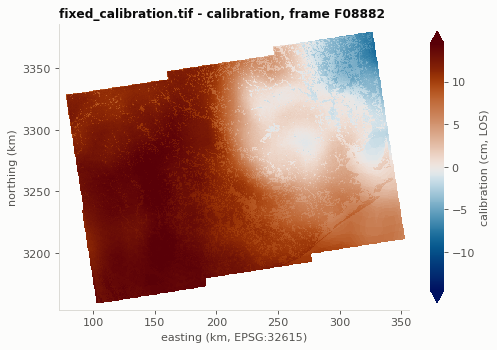

In [9]:
import matplotlib.pyplot as plt

SURFACE, INK, MUTED, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({
    "figure.dpi": 80, "savefig.dpi": 80, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#d9d8d2", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
from cal_disp.browse_image import DEFAULT_CMAP, symmetric_limits

vmin, vmax = symmetric_limits(preview)
fig, ax = plt.subplots(figsize=(6.4, 4.6))
im = ax.imshow(preview * 100, extent=extent, cmap=DEFAULT_CMAP, vmin=vmin * 100, vmax=vmax * 100, interpolation="nearest")
ax.set_xlabel(f"easting (km, EPSG:{product.get_epsg()})")
ax.set_ylabel("northing (km)")
ax.set_title("fixed_calibration.tif - calibration, frame F08882")
cb = fig.colorbar(im, ax=ax, shrink=0.85, extend="both")
cb.set_label("calibration (cm, LOS)")
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

## Summary

* Golden product: `spatial_ref` had no `GeoTransform` (and lost `units`/`long_name`);
  `CalProduct.to_geotiff` raised `ValueError`.
* Fixed product: every DISP `spatial_ref` attribute is kept with the same value, including
  `GeoTransform = "71970.0 30.0 0.0 3385920.0 0.0 -30.0"`; the exported GeoTIFF has the DISP
  grid's transform and CRS and the layer's exact values. `/auxiliary` has the transform of
  its own coarse grid.